In [ ]:
import gc
import sys
sys.path.append("/home/david/source/psilocybin-eeg")

from pathlib import Path
import pandas as pd
import numpy as np
import mne
from src.data.dataset_handler import DatasetHandler
from src.definitions.fields import (
    SingleDataMetadata, 
    ChannelTypes, 
    ExperimentNames, 
    CoordinateSystems, 
    PreprocessedDataVariants, 
    ICLabelComponentsClasses, 
    ExcludedICsMetadata, 
    MusicTypeVariants, 
    ConditionVariants,
)
from src.definitions.constants import ProjectPaths

%matplotlib qt
# %matplotlib inline

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


In [3]:
dataset_handler = DatasetHandler(ExperimentNames.PSILO_MUSIC, CoordinateSystems.HYDROGEL_257_NO_FIDUCIALS)
dataset_metadata = pd.read_csv("/home/david/source/psilocybin-eeg/dataset_metadata.csv")
excluded_ics_metadata = pd.read_csv("/home/david/source/psilocybin-eeg/excluded_ics_mapping.csv")

# Selection of Condition for analysis

In [4]:
# Setup of the processing
participant_id = 24
music_type_enum = MusicTypeVariants.PSYTRANCE
condition_enum = ConditionVariants.PLACEBO

# Basic setup
music_mapping = {
    MusicTypeVariants.CLASSICAL: "MusicTypeVariants.CLASSICAL",
    MusicTypeVariants.PSYTRANCE: "MusicTypeVariants.PSYTRANCE"
}
condition_mapping = {
    ConditionVariants.PLACEBO: "ConditionVariants.PLACEBO",
    ConditionVariants.PSILOCYBIN: "ConditionVariants.PSILOCYBIN"
}

music_type = music_mapping[music_type_enum]
condition = condition_mapping[condition_enum]

df = dataset_metadata[dataset_metadata["SingleDataMetadata.PARTICIPANT_ID"] == participant_id]
df = df[df["SingleDataMetadata.MUSIC_TYPE"] == music_type]
df = df[df["SingleDataMetadata.CONDITION"] == condition]
print(df["SingleDataMetadata.EEG_CONDITION_ID"])
original_filename = df["SingleDataMetadata.FILENAME"].iloc[0]

keys_of_interest = [ExcludedICsMetadata.ORIGINAL_FILENAME.value, ExcludedICsMetadata.IC_ID.value, ExcludedICsMetadata.IC_CATEGORY.value, ExcludedICsMetadata.TIMESERIES_FILENAME.value]
df = excluded_ics_metadata[keys_of_interest]
excluded_df = df[df[ExcludedICsMetadata.ORIGINAL_FILENAME.value] == original_filename]


40    EEGConditions.CONDITION_B
Name: SingleDataMetadata.EEG_CONDITION_ID, dtype: object


# Dataseries Analysis

In [5]:
try:
    del before_ica, after_ica
    gc.collect()
except NameError:
    pass

before_ica = dataset_handler.load_data_file(original_filename, is_processed=True, processed_data_type=PreprocessedDataVariants.RAW_BEFORE_ICA)
after_ica = dataset_handler.load_data_file(original_filename, is_processed=True, processed_data_type=PreprocessedDataVariants.RAW_AFTER_ICA)

Opening raw data file /home/david/source/psilocybin-eeg/data/processed/psilo_music/before_ica/PSI024_EEGB_MUSIC_PSYTRANCE_EC_20170919_014214.fif...
    Range : 10000 ... 519199 =     10.000 ...   519.199 secs
Ready.
Reading 0 ... 509199  =      0.000 ...   509.199 secs...


/home/david/source/psilocybin-eeg/src/data/dataset_handler.py:155: RuntimeWarning: This filename (/home/david/source/psilocybin-eeg/data/processed/psilo_music/before_ica/PSI024_EEGB_MUSIC_PSYTRANCE_EC_20170919_014214.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


Opening raw data file /home/david/source/psilocybin-eeg/data/processed/psilo_music/after_ica/PSI024_EEGB_MUSIC_PSYTRANCE_EC_20170919_014214.fif...
    Range : 10000 ... 519199 =     10.000 ...   519.199 secs
Ready.
Reading 0 ... 509199  =      0.000 ...   509.199 secs...


/home/david/source/psilocybin-eeg/src/data/dataset_handler.py:155: RuntimeWarning: This filename (/home/david/source/psilocybin-eeg/data/processed/psilo_music/after_ica/PSI024_EEGB_MUSIC_PSYTRANCE_EC_20170919_014214.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


### Plot Before ICA

Using matplotlib as 2D backend.


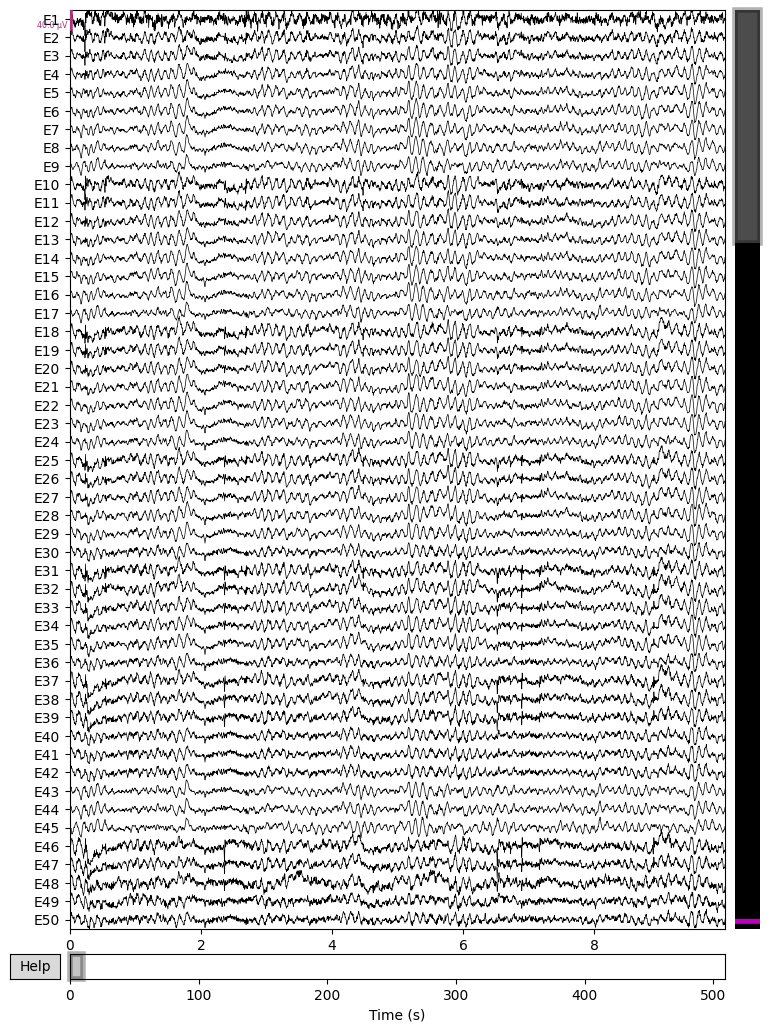

In [6]:
before_ica.plot(n_channels=50)

### Plot After ICA

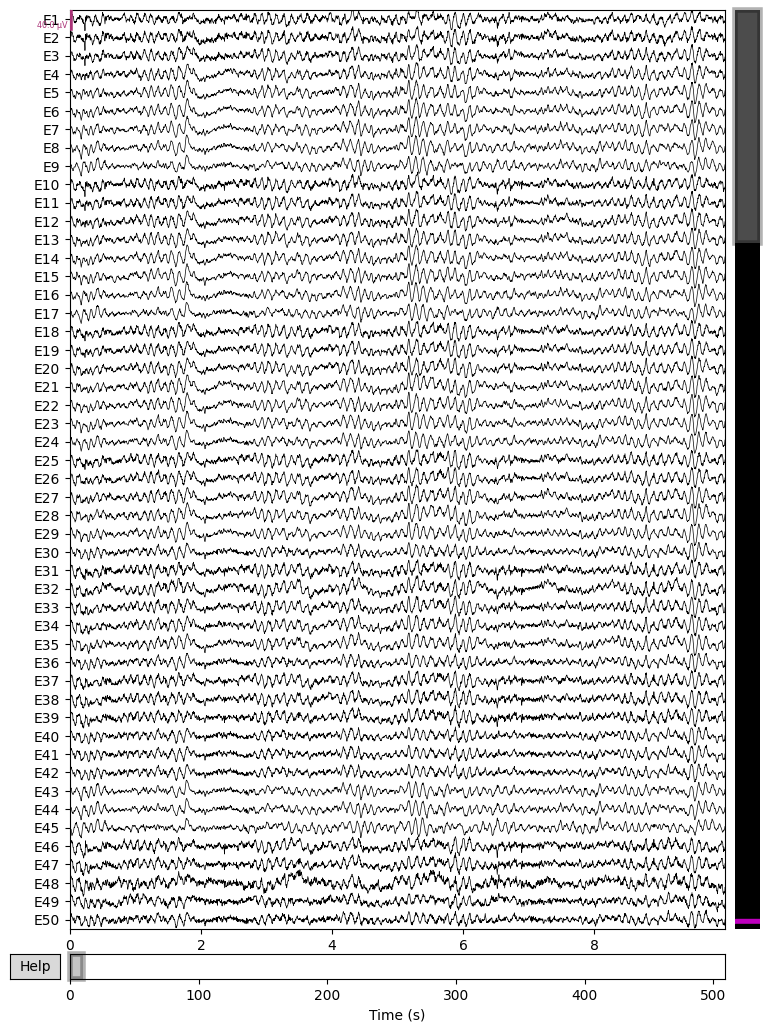

In [7]:
after_ica.plot(n_channels=50)

# Excluded ICs processing

In [8]:
excluded_df[[ExcludedICsMetadata.IC_ID.value, ExcludedICsMetadata.IC_CATEGORY.value]]

,ic_id,ic_category
672,13,ICLabelComponentsClasses.EYE
673,16,ICLabelComponentsClasses.EYE
674,17,ICLabelComponentsClasses.MUSCLE
675,19,ICLabelComponentsClasses.MUSCLE
676,22,ICLabelComponentsClasses.MUSCLE
677,28,ICLabelComponentsClasses.EYE
678,29,ICLabelComponentsClasses.MUSCLE
679,36,ICLabelComponentsClasses.MUSCLE
680,44,ICLabelComponentsClasses.MUSCLE
681,49,ICLabelComponentsClasses.MUSCLE


### Plot Excluded IC

Opening raw data file /home/david/source/psilocybin-eeg/data/processed/psilo_music/raw_excluded_ic/PSI024_EEGB_MUSIC_PSYTRANCE_EC_20170919_014214_IC-13_eog.fif...
    Range : 10000 ... 519199 =     10.000 ...   519.199 secs
Ready.
Reading 0 ... 509199  =      0.000 ...   509.199 secs...


/home/david/source/psilocybin-eeg/src/data/dataset_handler.py:155: RuntimeWarning: This filename (/home/david/source/psilocybin-eeg/data/processed/psilo_music/raw_excluded_ic/PSI024_EEGB_MUSIC_PSYTRANCE_EC_20170919_014214_IC-13_eog.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


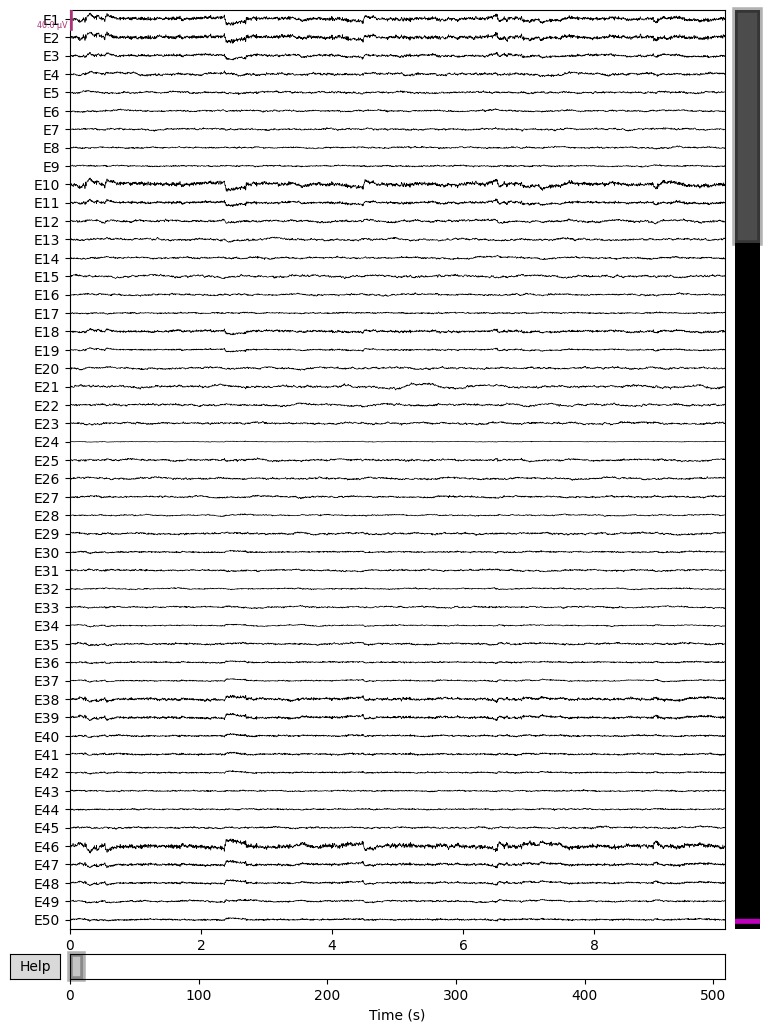

In [ ]:
excluded_ic_idx = 13

try:
    del before_ica, after_ica
    gc.collect()
except NameError:
    pass

try:
    del excluded_data
    gc.collect()
except NameError:
    pass

df = excluded_df[excluded_df[ExcludedICsMetadata.IC_ID.value] == excluded_ic_idx]
original_filename = df[ExcludedICsMetadata.ORIGINAL_FILENAME.value].iloc[0]
excluded_data = dataset_handler.load_excluded_ic_dataseries(original_filename, excluded_ic_idx)
ic_probabilities = dataset_handler.load_data_file(original_filename, is_processed=True, processed_data_type=PreprocessedDataVariants.IC_PROBABILITIES)

for i, label in enumerate(dataset_handler.dataset_preprocessor.ic_label_classes_order):
    print(f"{label}: {ic_probabilities[excluded_ic_idx, i]}")
excluded_data.plot(n_channels=50)


### Plot Broadband unnormalized signal

Effective window size : 2.048 (s)


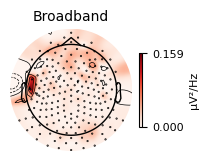

In [22]:
spectrum = excluded_data.compute_psd(fmin=0.5, fmax=100)  # Adjust fmax based on your sampling rate

# Plot topomap of total power across all frequencies
spectrum.plot_topomap(ch_type='eeg', bands={'Broadband': (0.5, 100)}, normalize=True)

### Plot normalized signal

In [11]:
after_ica = dataset_handler.load_data_file(original_filename, is_processed=True, processed_data_type=PreprocessedDataVariants.RAW_AFTER_ICA)
spectrum = after_ica.compute_psd(fmin=0.5, fmax=100)  # Adjust fmax based on your sampling rate

spectrum.plot_topomap(ch_type='eeg', normalize=True)

try:
    del after_ica
    gc.collect()
except NameError:
    pass

Opening raw data file /home/david/source/psilocybin-eeg/data/processed/psilo_music/after_ica/PSI018_EEGB_MUSIC_CLASSIC_EC_20180122_125335.fif...
    Range : 10000 ... 423799 =     10.000 ...   423.799 secs
Ready.
Reading 0 ... 413799  =      0.000 ...   413.799 secs...


/home/david/source/psilocybin-eeg/src/data/dataset_handler.py:155: RuntimeWarning: This filename (/home/david/source/psilocybin-eeg/data/processed/psilo_music/after_ica/PSI018_EEGB_MUSIC_CLASSIC_EC_20180122_125335.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


Effective window size : 2.048 (s)


### Plot sensor distribution

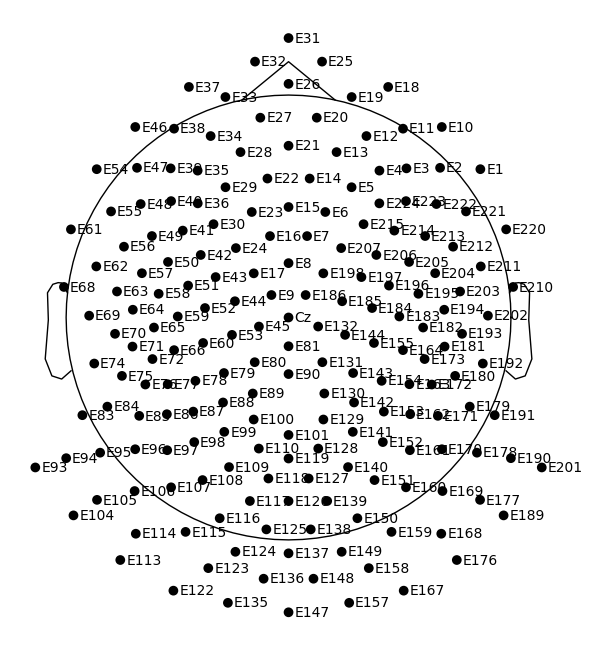

In [9]:
excluded_data.plot_sensors(show_names=True)